## Ash Kuinkel ~ cosc102 assignment 2 (Please run all cells in sequential order, or click "run all" at the top for a smoother experience)

### Brief Overview (Description of the program):
This program is crafted in a single section to accomplish our task as listed below;

Firstly, what is classification? Classification is a supervised machine learning task which relies on labelled data (i.e. input data labelled with what class they belong to), learns from this & uses this information learnt to be able to predict which new unseen items belong to which class. Our given task, follows a textbook application of modelling a classification workflow.

**Wine-Cultivar Classification** - We are required to apply a classifier algorithm of our liking to create a classifier which is able to classify the cultivar (specific type of grape grown in the vineyard) of wines from vineyards grown within the same region in Italy based upon 2 of the highest performing features ( selected using cross validation) out of the 13 available. A general gist/speculation on why only 2 features, will be provided further down below. The general set of steps that should be followed have been provided in the task description; loading dataset/partitioning, feature selection using cross validation, creating confusion matrix of classifiers performance on test set as well as calculating recall/precision/f1 scores, plotting & calculating ROC/AUC for each of the classes, demonstrating decision boundaries learnt by classifier w/ testing data points included in the form of a visual, i.e. scatter plot.


*I want to present my findings/what I have learnt for each of the steps (as this is how I worked through the assignment, step by step). So lets begin with what I first did, downloading and taking a look at the dataset.*

There were 2 things that stood out to me; a file named **wine.data** (which was of less importance) containing the 178 entries of all the different wines within the dataset & **wine.names** (of more importance) which specified what the dataset is actually containing. So from the wine.names I found that this dataset was derived from a chemical analysis, of wines in same region of Italy containing 3 different cultivars, which determined quantities of 13 chemical elements/parts found within each of the 3 types of wines. Also it lists that the author initially had approx. 30 variables instead of 13, but it appears that the author has lost the initial dataset. Anyways, the 13 features are listed here:

 	1) Alcohol
 	2) Malic acid
 	3) Ash
	4) Alcalinity of ash  
 	5) Magnesium
	6) Total phenols
 	7) Flavanoids
 	8) Nonflavanoid phenols
 	9) Proanthocyanins
	10)Color intensity
 	11)Hue
 	12)OD280/OD315 of diluted wines
 	13)Proline     

& we also see the number of instances of each class, i.e. (how many of the 178 entries belong to either class 1, 2 & 3):

    class 1 59
	class 2 71
	class 3 48 

This raises a subtle thought/question for me... It seems as if there are a little bit more instances of class 2, than class 1 or 3, so **should we automatically assume that the classifier will have some inclination to predict class 2 more often than the others (especially as we get closer to decision boundaries)?** But on second thought, I realise that the imbalance between the classes is very minimal. Either way, this is something to keep an eye on as we proceed through the later steps.

### <u>Step 1 (Load dataset and partition dataset in the train/test sets):</u>

Lets first begin by importing the required libraries/modules that we will need to make use of throughout the program.

sample test program to ensure everything is working first before writing out the notebook:

(A major talking point is about how i found RFECV but it only allows you to set the min number of features but not the max/how many features u want).... so I had to combine the RFE and cross val score in my own way...

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import RFECV

data = load_wine()

X,y = data["data"],data["target"]

# patition data into training/test:
X_train,X_test,y_train,y_test = train_test_split(X,y)

# train sgdclassifier:
#sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train)

# cross validation:
#y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/

#scores = cross_val_score(sgd_clf,X,y,cv=5)


#print(scores)

estimator = SGDClassifier(random_state=42)
selector = RFECV(estimator,step=1,cv=5)
selector = selector.fit(X, y)
print(selector.support_)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import RFE

data = load_wine()

X,y = data["data"],data["target"]

# patition data into training/test:
X_train,X_test,y_train,y_test = train_test_split(X,y)

# train sgdclassifier:
#sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train)

# cross validation:
#y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/

#scores = cross_val_score(sgd_clf,X,y,cv=5)


#print(scores)

estimator = SGDClassifier(random_state=0)
selector = RFE(estimator,n_features_to_select=2)
scores = cross_val_score(selector, X_train, y_train, cv=5)
selector.fit(X_train,y_train)
print("Top performing features within feature selection using CV: %d" % selector.n_features_)

print(selector.ranking_)


#top_performing_features_scores = cross_val_predict(selector.n_features[i], X, y)

Top performing features within feature selection using CV: 2
[ 1  6 10  2  3  8  5 12  9  1 11  7  4]


I just realised I've been approaching this in the wrong way.... RFE/RFECV is not good enough because we want 2 most higher performing features, so we will literally have to pick out all possible combinations of 2 features, 13 choose 2 so 78 total combinations and pick the one that scores the highest with the confusion matrix, f1 scores etc.... Once I follow it like that it should be quite easy to get this part done...

Best feature 1: 11 which is also labelled: od280/od315_of_diluted_wines
Best feature 2: 12 which is also labelled: proline
Best mean F1: 0.9028337562820322
Confusion Matrix:
 [[16  0  0]
 [ 1 18  2]
 [ 1  0  7]]
Recall Score : [1.         0.85714286 0.875     ]
Precision Score : [0.88888889 1.         0.77777778]
F1 score: [0.94117647 0.92307692 0.82352941]
{0: 0.997844827586207, 1: 0.9781746031746031, 2: 0.9527027027027026}


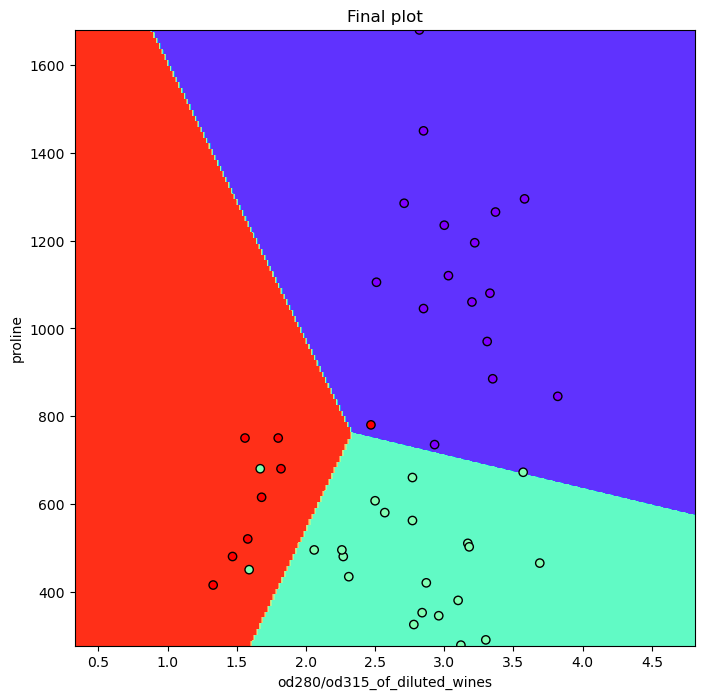

In [4]:
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.metrics import confusion_matrix,f1_score,recall_score,precision_score,roc_curve,auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

data = load_wine()

X,y = data["data"],data["target"]

# partition data into training/test: Step 1
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

# feature selection (highest performing features based upon cross-validation on training set) STep 2
best_mean_f1 = 0
best_feature1 = 0
best_feature2 = 0

for feature1 in range(13):
    for feature2 in range(13):
        
        if feature1 == feature2:
            continue
        
        idx = [feature1,feature2]
        
        sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
        sgd_clf.fit(X_train[:,idx],y_train)
        
        y_pred = cross_val_predict(sgd_clf,X_train[:,idx],y_train,cv=5)\
        
        curr_mean_f1 = np.mean(f1_score(y_train,y_pred,average=None))
        
        if curr_mean_f1 > best_mean_f1:
            best_mean_f1 = curr_mean_f1
            best_feature1 = feature1
            best_feature2 = feature2

print("Best feature 1: %d " % best_feature1 + "which is also labelled: %s" % data.feature_names[best_feature1])
print("Best feature 2: %d " % best_feature2 + "which is also labelled: %s" % data.feature_names[best_feature2])
print(f"Best mean F1: {best_mean_f1}")

# Step 3
best_features_idx = [best_feature1,best_feature2]

sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
sgd_clf.fit(X_train[:,best_features_idx],y_train)

y_pred = sgd_clf.predict(X_test[:,best_features_idx])

# & Make sure we are visualising this confusion matrix.... 
conf_matrix = confusion_matrix(y_test,y_pred)

print(f"Confusion Matrix:\n {conf_matrix}")

recall = recall_score(y_test,y_pred,average=None)
precision = precision_score(y_test,y_pred,average=None)
f1 = f1_score(y_test,y_pred,average=None)

print(f"Recall Score : {recall}" )
print(f"Precision Score : {precision}" )  
print(f"F1 score: {f1}" )      

y_scores = sgd_clf.decision_function(X_test[:,best_features_idx])

y_test_bin = label_binarize(y_test,classes=[0,1,2])
false_positive_rate = dict()
true_positive_rate = dict()
roc_auc = dict()

for i in range(3):
    false_positive_rate[i],true_positive_rate[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i])
    roc_auc[i] = auc(false_positive_rate[i],true_positive_rate[i])
# & Also make sure we plot these roc curves for each of the classes along with the AUC..
# & how we should interpret the results
print(roc_auc)


X_train_selected = X_train[:,best_features_idx]
X_test_selected = X_test[:,best_features_idx]

# creating the mesh to plot in:
x_min, x_max = X_test[:,best_feature1].min() - 1, X_test[:,best_feature1].max() + 1
y_min, y_max = X_test[:,best_feature2].min() - 1, X_test[:,best_feature2].max() + 1

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.2))

grid_predictions = sgd_clf.predict(np.c_[xx.ravel(),yy.ravel()])

# putting result into colour shape:
grid_predictions = grid_predictions.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8,8))

ax.contourf(xx,yy,grid_predictions,cmap="rainbow")

ax.scatter(X_test_selected[:,0],X_test_selected[:,1],c=y_test,cmap="rainbow",edgecolor="black")

plt.xlabel(data.feature_names[best_feature1])
plt.ylabel(data.feature_names[best_feature2])
plt.title("Final plot")

plt.show()

